In [1]:
import matplotlib.pyplot as plt
import numpy as np

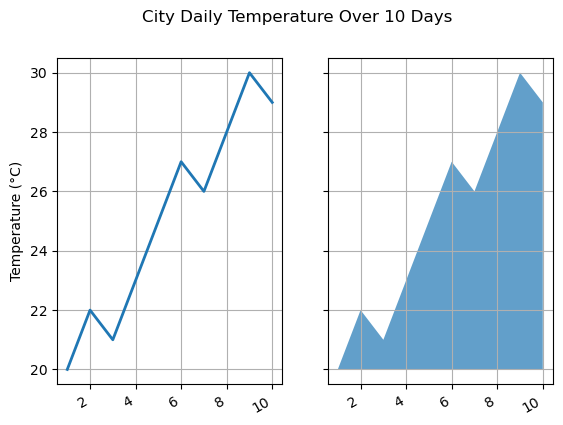

In [3]:
# 假设我们有10天的温度数据
days = np.arange(1, 11)
temperature = np.array([20, 22, 21, 23, 25, 27, 26, 28, 30, 29])

# 创建两个子图，x轴和y轴共享
fig, (ax1, ax2) = plt.subplots(1, 2, sharex=True, sharey=True)

temp_min = temperature.min()

# 子图1：折线图
ax1.plot(days, temperature, lw=2, label="Temperature (°C)")
# 子图2：填充图
ax2.fill_between(days, temp_min, temperature, alpha=0.7, label="Temperature Range")

# 为两个子图添加网格
for ax in (ax1, ax2):
    ax.grid(True)
    ax.label_outer()

# 设置y轴标签
ax1.set_ylabel('Temperature (°C)')

# 设置总标题
fig.suptitle('City Daily Temperature Over 10 Days')

# 自动调整x轴标签角度
fig.autofmt_xdate()

plt.show()

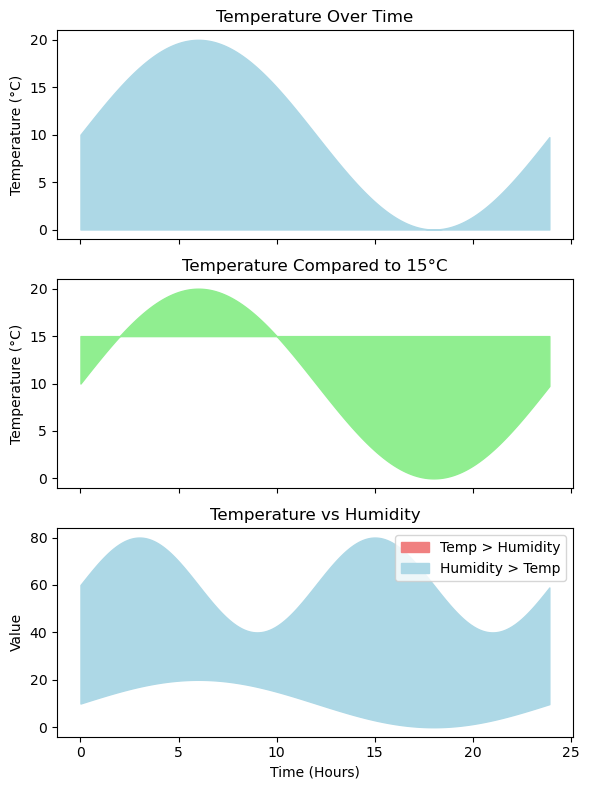

In [5]:
# 创建时间序列，表示一天中的小时数（0到24小时）
hours = np.arange(0.0, 24, 0.1)

# 假设温度和湿度随时间变化的波动曲线
temperature = 10 + 10 * np.sin(2 * np.pi * hours / 24)  # 温度在10°C到20°C之间波动
humidity = 60 + 20 * np.sin(4 * np.pi * hours / 24)     # 湿度在40%到80%之间波动

# 创建三个子图，共享x轴（时间）
fig, (ax1, ax2, ax3) = plt.subplots(3, 1, sharex=True, figsize=(6, 8))

# 图1：填充温度曲线下方区域
ax1.fill_between(hours, temperature, color="lightblue")
ax1.set_title('Temperature Over Time')
ax1.set_ylabel('Temperature (°C)')

# 图2：填充温度曲线与固定值（15°C）之间的区域
ax2.fill_between(hours, temperature, 15, color="lightgreen")
ax2.set_title('Temperature Compared to 15°C')
ax2.set_ylabel('Temperature (°C)')

# 图3：填充温度曲线与湿度曲线之间的区域
ax3.fill_between(hours, temperature, humidity, where=(temperature > humidity), color="lightcoral", label="Temp > Humidity")
ax3.fill_between(hours, temperature, humidity, where=(temperature <= humidity), color="lightblue", label="Humidity > Temp")
ax3.set_title('Temperature vs Humidity')
ax3.set_xlabel('Time (Hours)')
ax3.set_ylabel('Value')
ax3.legend()

# 调整布局，避免重叠
fig.tight_layout()

plt.show()


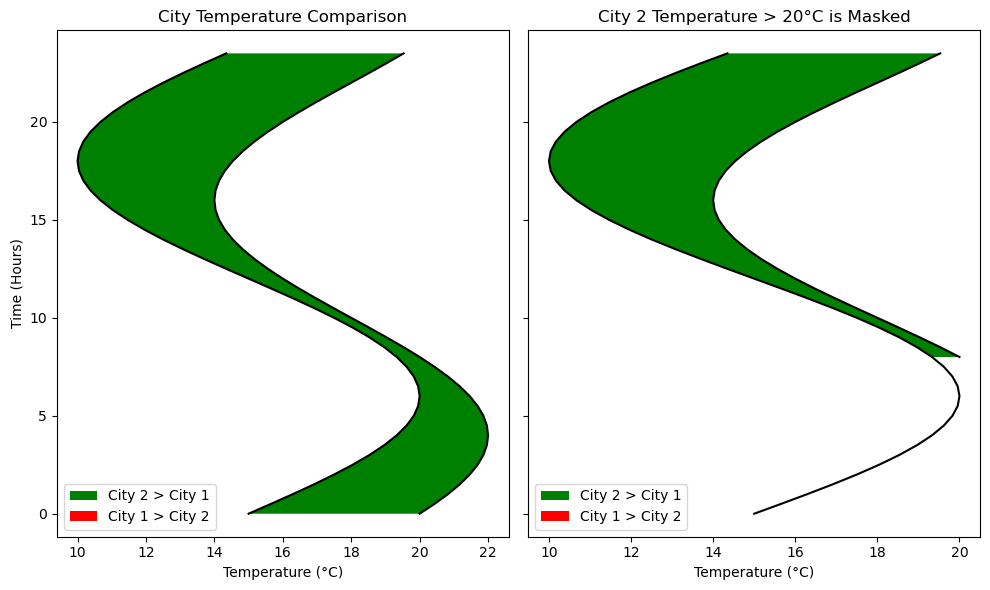

In [7]:
# 假设我们有两个城市一天的温度数据，时间以小时表示
hours = np.arange(0, 24, 0.5)
city1_temp = 15 + 5 * np.sin(2 * np.pi * hours / 24)  # 城市1的温度变化，波动在10°C到20°C之间
city2_temp = 18 + 4 * np.sin(2 * np.pi * hours / 24 + np.pi / 6)  # 城市2的温度变化，波动在14°C到22°C之间

# 创建两个子图，y轴（温度）共享
fig, [ax, ax1] = plt.subplots(1, 2, sharey=True, figsize=(10, 6))

# 子图1：城市1和城市2的温度对比，填充颜色表示哪一个城市温度较高
ax.plot(city1_temp, hours, city2_temp, hours, color='black')
ax.fill_betweenx(hours, city1_temp, city2_temp, where=city2_temp >= city1_temp, facecolor='green', label='City 2 > City 1')
ax.fill_betweenx(hours, city1_temp, city2_temp, where=city2_temp <= city1_temp, facecolor='red', label='City 1 > City 2')
ax.set_title('City Temperature Comparison')
ax.set_xlabel('Temperature (°C)')
ax.set_ylabel('Time (Hours)')
ax.legend()

# 子图2：掩盖掉城市2温度高于20°C的部分（模拟数据不显示这些区域）
city2_temp_masked = np.ma.masked_greater(city2_temp, 20)

ax1.plot(city1_temp, hours, city2_temp_masked, hours, color='black')
ax1.fill_betweenx(hours, city1_temp, city2_temp_masked, where=city2_temp_masked >= city1_temp, facecolor='green', label='City 2 > City 1')
ax1.fill_betweenx(hours, city1_temp, city2_temp_masked, where=city2_temp_masked <= city1_temp, facecolor='red', label='City 1 > City 2')
ax1.set_title('City 2 Temperature > 20°C is Masked')
ax1.set_xlabel('Temperature (°C)')
ax1.legend()

# 调整布局
fig.tight_layout()

plt.show()


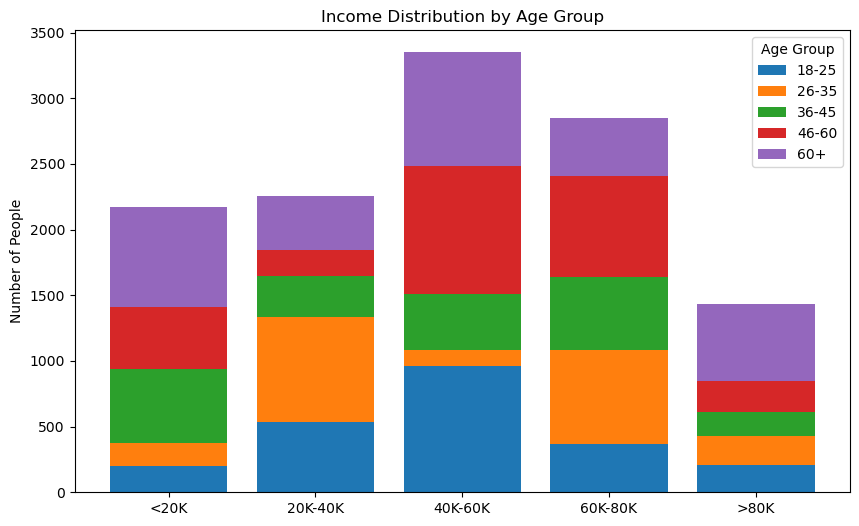

In [9]:
import matplotlib.pyplot as plt
import numpy as np
from functools import partial
from cycler import cycler

# 修改后的数据和绘图函数

# 模拟不同年龄段人群的收入分布
age_groups = ['18-25', '26-35', '36-45', '46-60', '60+']
income_levels = ['<20K', '20K-40K', '40K-60K', '60K-80K', '>80K']

# 生成每个年龄段不同收入水平的随机人数
np.random.seed(42)
stack_data = np.random.randint(100, 1000, size=(len(age_groups), len(income_levels)))

# 定义边缘：每个收入水平代表一个区间
edges = np.arange(len(income_levels) + 1)

# 直方图的函数
def filled_bar_hist(ax, edges, values, bottoms=None, **kwargs):
    if bottoms is None:
        bottoms = np.zeros_like(values)
    ax.bar(np.arange(len(values)), values, bottom=bottoms, **kwargs)
    ax.set_xticks(np.arange(len(income_levels)))
    ax.set_xticklabels(income_levels)
    return ax

# 设置样式循环
color_cycle = cycler(facecolor=plt.rcParams['axes.prop_cycle'][:len(age_groups)])
label_cycle = cycler(label=age_groups)

# 绘制堆叠的条形图
fig, ax = plt.subplots(figsize=(10, 6))

def stack_hist_bar(ax, stacked_data, labels, colors):
    bottoms = np.zeros(stacked_data.shape[1])
    for i, (data, label, color) in enumerate(zip(stacked_data, labels, colors)):
        ax.bar(np.arange(len(income_levels)), data, bottom=bottoms, label=label, color=color['facecolor'])
        bottoms += data
    ax.set_xticks(np.arange(len(income_levels)))
    ax.set_xticklabels(income_levels)
    ax.legend(title='Age Group')
    ax.set_ylabel('Number of People')
    ax.set_title('Income Distribution by Age Group')
    
# 获取颜色和标签
colors = list(color_cycle)
labels = [label['label'] for label in label_cycle]

# 调用绘制函数
stack_hist_bar(ax, stack_data, labels, colors)

plt.show()


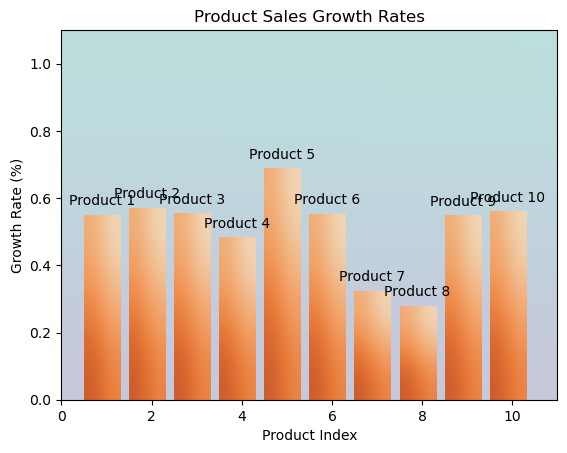

In [11]:
import matplotlib.pyplot as plt  
import numpy as np  
  
np.random.seed(19680801)  
  
def gradient_image(ax, direction=0.3, cmap_range=(0, 1), **kwargs):  
    """  
    Draw a gradient image based on a colormap.  
    """  
    phi = direction * np.pi / 2  
    v = np.array([np.cos(phi), np.sin(phi)])  
    X = np.array([[v @ [1, 0], v @ [1, 1]],  
                  [v @ [0, 0], v @ [0, 1]]])  
    a, b = cmap_range  
    X = a + (b - a) / X.max() * X  
    im = ax.imshow(X, interpolation='bicubic', clim=(0, 1),  
                   aspect='auto', **kwargs)  
    return im  
  
def gradient_bar(ax, x, y, labels=None, width=0.5, bottom=0, cmap=plt.cm.Blues_r, cmap_range=(0, 0.8)):  
    for left, top, label in zip(x, y, labels):  
        right = left + width  
        gradient_image(ax, extent=(left, right, bottom, top),  
                       cmap=cmap, cmap_range=cmap_range, alpha=0.8)  
        if label:  
            ax.text(left + width / 2, top + 0.02, label, ha='center', va='bottom')  
  
fig, ax = plt.subplots()  
ax.set(xlim=(0, 11), ylim=(0, 1.1))  
  
# 背景图像，表示市场增长趋势  
gradient_image(ax, direction=0.5, extent=(0, 10, 0, 1), transform=ax.transAxes,  
               cmap=plt.cm.viridis, cmap_range=(0.2, 0.8), alpha=0.3)  
  
# 产品销售额增长率  
N = 10  
x = np.arange(N) + 0.5  
y = np.random.rand(N) * 0.5 + 0.2  # 假设增长率在20%到70%之间  
labels = ['Product ' + str(i+1) for i in range(N)]  
gradient_bar(ax, x, y, labels=labels, width=0.8, cmap=plt.cm.Oranges_r, cmap_range=(0.2, 0.8))  
  
# 添加标题和坐标轴标签  
ax.set_title('Product Sales Growth Rates')  
ax.set_xlabel('Product Index')  
ax.set_ylabel('Growth Rate (%)')  
  
plt.show()

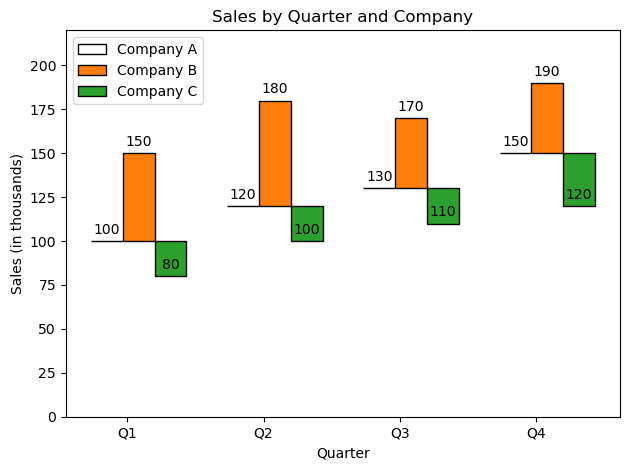

In [15]:
def hat_graph(ax, xlabels, values, group_labels):  
    """  
    Create a hat graph.  
  
    Parameters  
    ----------  
    ax : matplotlib.axes.Axes  
        The Axes to plot into.  
    xlabels : list of str  
        The time period names to be displayed on the x-axis.  
    values : (M, N) array-like  
        The data values.  
        Rows are the entities (len(group_labels) == M).  
        Columns are the time periods (len(xlabels) == N).  
    group_labels : list of str  
        The entity labels displayed in the legend.  
    """  
  
    def label_bars(heights, rects):  
        """Attach a text label on top of each bar."""  
        for height, rect in zip(heights, rects):  
            ax.annotate(f'{height}',  
                        xy=(rect.get_x() + rect.get_width() / 2, height),  
                        xytext=(0, 3),  # 3 points vertical offset.  
                        textcoords='offset points',  
                        ha='center', va='bottom')  
  
    values = np.asarray(values)  
    x = np.arange(values.shape[1])  
    ax.set_xticks(x, labels=xlabels)  
    spacing = 0.3  # spacing between hat groups  
    width = (1 - spacing) / values.shape[0]  
    heights0 = values[0]  
    for i, (heights, group_label) in enumerate(zip(values, group_labels)):  
        style = {'fill': False} if i == 0 else {'edgecolor': 'black'}  
        rects = ax.bar(x - spacing/2 + i * width, heights - heights0,  
                       width, bottom=heights0, label=group_label, **style)  
        label_bars(heights, rects)  
  
# initialise labels and a numpy array  
# Each row represents a company's sales for each quarter  
xlabels = ['Q1', 'Q2', 'Q3', 'Q4']  
companyA = np.array([100, 120, 130, 150])  
companyB = np.array([150, 180, 170, 190])  
companyC = np.array([80, 100, 110, 120])  
  
fig, ax = plt.subplots()  
hat_graph(ax, xlabels, [companyA, companyB, companyC], ['Company A', 'Company B', 'Company C'])  
  
# Add some text for labels, title and custom x-axis tick labels, etc.  
ax.set_xlabel('Quarter')  
ax.set_ylabel('Sales (in thousands)')  
ax.set_ylim(0, 220)  
ax.set_title('Sales by Quarter and Company')  
ax.legend()  
  
fig.tight_layout()  
plt.show()

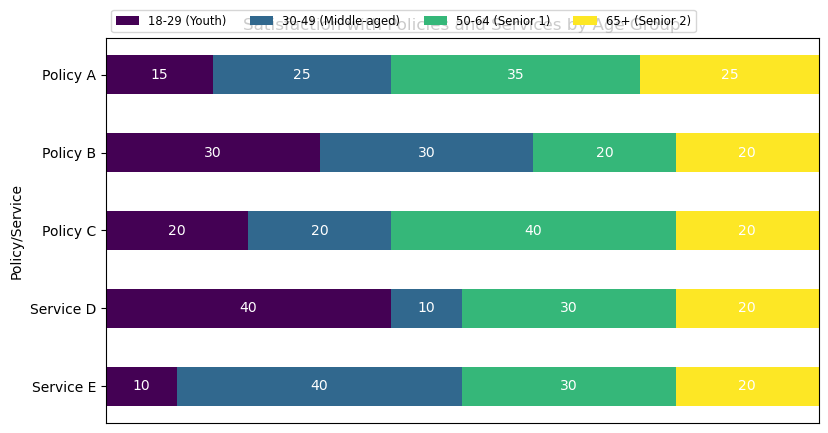

In [17]:
# 新的类别名称，代表不同的年龄段  
age_groups = ['18-29 (Youth)', '30-49 (Middle-aged)',  
              '50-64 (Senior 1)', '65+ (Senior 2)']  
  
# 新的调查结果，假设是对某个政策或服务满意度的调查  
survey_results = {  
    'Policy A': [15, 25, 35, 25],  # 对政策A的满意度  
    'Policy B': [30, 30, 20, 20],  # 对政策B的满意度  
    'Policy C': [20, 20, 40, 20],  # 对政策C的满意度  
    'Service D': [40, 10, 30, 20],  # 对服务D的满意度  
    'Service E': [10, 40, 30, 20]  # 对服务E的满意度  
}  
  
def survey(results, age_groups):  
    """  
    绘制关于不同年龄段对多项政策或服务满意度的堆叠条形图。  
  
    Parameters  
    ----------  
    results : dict  
        一个从政策/服务标签到各年龄段满意度的列表的映射。  
        假设所有列表包含相同数量的条目，且与 *age_groups* 的长度相匹配。  
    age_groups : list of str  
        年龄段的标签。  
    """  
    labels = list(results.keys())  
    data = np.array(list(results.values()))  
    data_cum = data.cumsum(axis=1)  
    age_colors = plt.cm.viridis(np.linspace(0, 1, data.shape[1]))  # 使用不同的颜色映射  
  
    fig, ax = plt.subplots(figsize=(9.2, 5))  
    ax.invert_yaxis()  # 将y轴翻转，以便从上到下是年龄增长  
    ax.xaxis.set_visible(False)  # 不显示x轴  
    ax.set_xlim(0, np.sum(data, axis=1).max())  # 设置x轴的范围  
  
    for i, (groupname, color) in enumerate(zip(age_groups, age_colors)):  
        widths = data[:, i]  
        starts = data_cum[:, i] - widths  
        rects = ax.barh(labels, widths, left=starts, height=0.5,  
                        label=groupname, color=color)  
  
        r, g, b, _ = color  
        text_color = 'white' if r * g * b < 0.5 else 'darkgrey'  
        ax.bar_label(rects, label_type='center', color=text_color)  
  
    ax.legend(ncols=len(age_groups), bbox_to_anchor=(0, 1),  
              loc='lower left', fontsize='small')  
    ax.set_yticks(np.arange(len(labels)))  
    ax.set_yticklabels(labels)  
    ax.set_ylabel('Policy/Service')  
    ax.set_title('Satisfaction with Policies and Services by Age Group')  
  
    return fig, ax  
  
survey(survey_results, age_groups)  
plt.show()